/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)



RESULTADOS DEL MODELO
Error absoluto medio: $41,421,796
Raíz del error cuadrático medio: $41,421,796
R²: nan

COEFICIENTES DEL MODELO
area_m2: $5,155,161.67
habitaciones: $6,141,556.55
banos: $11,250,778.83
antiguedad: $3,663,712.53
garajes: $6,141,556.55
Intercepto: $-216,117,842.89

DATOS DE LA CASA A PREDECIR
Área en metros cuadrados: 45
Número de habitaciones: 3
Número de baños: 2
Antigüedad en años: 1
Número de garajes: 1

PREDICCIÓN
Precio estimado de la casa: $66,595,929

Modelo guardado como: modelo_precios_casas.pkl


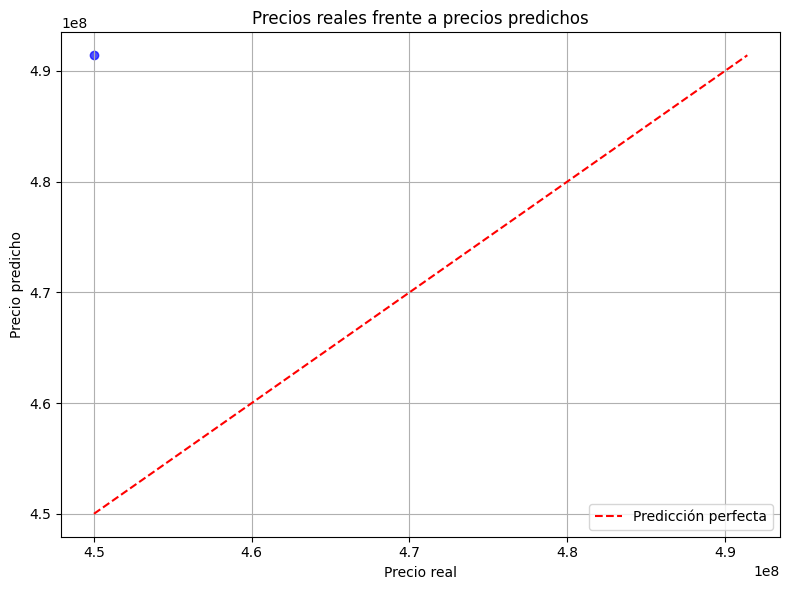

In [4]:
# prediccion_precios_casas.py

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==============================
# 1. Cargar el conjunto de datos
# ==============================

archivo = "/content/casas.csv"

try:
    datos = pd.read_csv(archivo)
except FileNotFoundError:
    print(f"No se encontró el archivo '{archivo}'.")
    print("Asegúrate de que esté en la misma carpeta que este script.")
    exit()


# ==============================
# 2. Preparar los datos
# ==============================

columnas_entrada = [
    "area_m2",
    "habitaciones",
    "banos",
    "antiguedad",
    "garajes"
]

columna_objetivo = "precio"

columnas_necesarias = columnas_entrada + [columna_objetivo]

if not all(columna in datos.columns for columna in columnas_necesarias):
    print("El archivo CSV debe contener estas columnas:")
    print(", ".join(columnas_necesarias))
    exit()

datos = datos[columnas_necesarias].dropna()

X = datos[columnas_entrada]
y = datos[columna_objetivo]


# ==============================
# 3. Separar entrenamiento y prueba
# ==============================

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ==============================
# 4. Entrenar el modelo
# ==============================

modelo = LinearRegression()
modelo.fit(X_entrenamiento, y_entrenamiento)


# ==============================
# 5. Evaluar el modelo
# ==============================

predicciones = modelo.predict(X_prueba)

mae = mean_absolute_error(y_prueba, predicciones)
rmse = mean_squared_error(y_prueba, predicciones) ** 0.5
r2 = r2_score(y_prueba, predicciones)

print("\nRESULTADOS DEL MODELO")
print("=====================")
print(f"Error absoluto medio: ${mae:,.0f}")
print(f"Raíz del error cuadrático medio: ${rmse:,.0f}")
print(f"R²: {r2:.4f}")


# ==============================
# 6. Mostrar la fórmula aprendida
# ==============================

print("\nCOEFICIENTES DEL MODELO")
print("=======================")

for nombre, coeficiente in zip(columnas_entrada, modelo.coef_):
    print(f"{nombre}: ${coeficiente:,.2f}")

print(f"Intercepto: ${modelo.intercept_:,.2f}")


# ==============================
# 7. Solicitar datos de una casa
# ==============================

print("\nDATOS DE LA CASA A PREDECIR")
print("============================")

try:
    area_m2 = float(input("Área en metros cuadrados: "))
    habitaciones = int(input("Número de habitaciones: "))
    banos = int(input("Número de baños: "))
    antiguedad = int(input("Antigüedad en años: "))
    garajes = int(input("Número de garajes: "))
except ValueError:
    print("Debes ingresar valores numéricos válidos.")
    exit()


casa_nueva = pd.DataFrame({
    "area_m2": [area_m2],
    "habitaciones": [habitaciones],
    "banos": [banos],
    "antiguedad": [antiguedad],
    "garajes": [garajes]
})


# ==============================
# 8. Realizar la predicción
# ==============================

precio_estimado = modelo.predict(casa_nueva)[0]

print("\nPREDICCIÓN")
print("==========")
print(f"Precio estimado de la casa: ${precio_estimado:,.0f}")


# ==============================
# 9. Guardar el modelo
# ==============================

nombre_modelo = "modelo_precios_casas.pkl"
joblib.dump(modelo, nombre_modelo)

print(f"\nModelo guardado como: {nombre_modelo}")


# ==============================
# 10. Guardar resultados de prueba
# ==============================

resultados = pd.DataFrame({
    "precio_real": y_prueba.values,
    "precio_predicho": predicciones
})

resultados.to_csv("resultados_predicciones.csv", index=False)


# ==============================
# 11. Mostrar gráfico
# ==============================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_prueba,
    predicciones,
    color="blue",
    alpha=0.7
)

valor_minimo = min(y_prueba.min(), predicciones.min())
valor_maximo = max(y_prueba.max(), predicciones.max())

plt.plot(
    [valor_minimo, valor_maximo],
    [valor_minimo, valor_maximo],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precios reales frente a precios predichos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
csv_content = """area_m2,habitaciones,banos,antiguedad,garajes,precio
80,3,2,10,1,280000000
120,4,3,5,2,450000000
60,2,1,20,0,190000000
150,4,4,3,2,650000000
95,3,2,8,1,350000000"""

with open('/content/casas.csv', 'w') as f:
    f.write(csv_content)

print("Contenido escrito en /content/casas.csv")

Contenido escrito en /content/casas.csv
